# Генерация русской поэзии: обучение Mamba на датасете Ars Poetica

Это третья часть учебного проекта по сравнению архитектур (LSTM, Transformer, Mamba) для генерации русской поэзии:

Структура полностью аналогична ноутбуку с LSTM: тот же датасет, тот же посимвольный словарь (с ударениями), то же разбиение на train/val, тот же формат сохраняемых артефактов $-$ чтобы дальше можно было сравнить модели.


In [ ]:
import os
import json
import math
import random
import time
from typing import Callable, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange

from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cpu"



## 1. Загрузка датасета

In [ ]:
dataset = load_dataset("inkoziev/ArsPoetica")
ds = dataset["train"]
print("Количество стихотворений:", len(ds))
print(ds[0])


Количество стихотворений: 8498
{'author': 'Николай Гумилёв', 'title': 'Аннам', 'poem_text': 'Месяц стоит посредине\nДивно-огромного неба,\nВетер в бамбуковой чаще,\nБлагоухающий воздух,\nБлагословенна семья.\n\nСтаршие в роще за чаем,\nПьют и стихи повторяют,\nИз дому слышно гуденье,\nТам занимаются дети,\nНоворождённый кричит.\n\nТот, кто живёт этой жизнью,\nПолное знает блаженство.\nЧто ему деньги и слава,\nЕсли он верит, что детям\nДолжно его пережить?', 'accentuation': 'Ме́сяц стои́т посреди́не\nДи́вно - огро́много не́ба,\nВе́тер в бамбу́ковой ча́ще,\nБла̀гоуха́ющий во́здух,\nБлагослове́нна семья́.\n\nСта́ршие в ро́ще за ча́ем,\nПью́т и стихи́ повторя́ют,\nИ́з дому слы́шно гуде́нье,\nТа́м занима́ются де́ти,\nНо̀ворождё́нный кричи́т.\n\nТо́т, кто живё́т этой жи́знью,\nПо́лное зна́ет блаже́нство.\nЧто́ ему де́ньги и сла́ва,\nЕ́сли он ве́рит, что де́тям\nДо́лжно его́ пережи́ть?'}


## Параллельный scan (`PScan`)
> За основу была взята структура кода с семинаров.



In [ ]:
class PScan(Function):
    @staticmethod
    def forward(ctx, A_inp, X_inp):
        A, X = A_inp.clone(), X_inp.clone()
        A, X = rearrange(A, "l b d s -> b d l s"), rearrange(X, "l b d s -> b d l s")
        A_orig = A.clone()  
        PScan._forward(A, X)
        ctx.save_for_backward(A_orig, X)
        return rearrange(X, "b d l s -> b l d s")

    @staticmethod
    def backward(ctx, grad_inp: Tensor) -> Tuple[Tensor, Tensor]:
        A, X = ctx.saved_tensors
        A = torch.cat((A[:, :, :1], A[:, :, 1:].flip(2)), dim=2)
        grad_out = rearrange(grad_inp, "b l d s -> b d l s")
        grad_out = grad_out.flip(2)
        PScan._forward(A, grad_out)
        grad_out = grad_out.flip(2)
        Q = torch.zeros_like(X)
        Q[:, :, 1:].add_(X[:, :, :-1] * grad_out[:, :, 1:])
        return rearrange(Q, "b d l s -> l b d s"), rearrange(grad_out, "b d l s -> l b d s")

    @staticmethod
    def _forward(A: Tensor, X: Tensor) -> None:
        b, d, l, s = A.shape
        num_steps = int(math.log2(l))
        Av, Xv = A, X
        for _ in range(num_steps):
            T = Xv.size(2)
            Av, Xv = Av[:, :, :T].reshape(b, d, T // 2, 2, -1), Xv[:, :, :T].reshape(b, d, T // 2, 2, -1)
            Xv[:, :, :, 1].add_(Av[:, :, :, 1].mul(Xv[:, :, :, 0]))
            Av[:, :, :, 1].mul_(Av[:, :, :, 0])
            Av, Xv = Av[:, :, :, 1], Xv[:, :, :, 1]
        for k in range(num_steps - 1, -1, -1):
            Av, Xv = A[:, :, 2**k - 1: l: 2**k], X[:, :, 2**k - 1: l: 2**k]
            T = 2 * (Xv.size(2) // 2)
            if T < Xv.size(2):
                Xv[:, :, -1].add_(Av[:, :, -1].mul(Xv[:, :, -2]))
                Av[:, :, -1].mul_(Av[:, :, -2])
            Av, Xv = Av[:, :, :T].reshape(b, d, T // 2, 2, -1), Xv[:, :, :T].reshape(b, d, T // 2, 2, -1)
            Xv[:, :, 1:, 0].add_(Av[:, :, 1:, 0].mul(Xv[:, :, :-1, 1]))
            Av[:, :, 1:, 0].mul_(Av[:, :, :-1, 1])

pscan: Callable[[Tensor, Tensor], Tensor] = PScan.apply


In [ ]:
torch.manual_seed(0)
A_check = (torch.rand(16, 2, 3, 4, dtype=torch.float64) * 0.5 + 0.3).requires_grad_(True)
X_check = torch.randn(16, 2, 3, 4, dtype=torch.float64).requires_grad_(True)
ok = torch.autograd.gradcheck(pscan, (A_check, X_check), eps=1e-6, atol=1e-4)
print("gradcheck PScan:", "OK" if ok else "FAILED")


gradcheck PScan: OK


Замечание: `PScan` работает только для длины последовательности, равной степени двойки. Реальные стихи такой длины не имеют, поэтому в SSM-блоке ниже последовательность перед сканом дополняется нулями до следующей степени двойки, а после обрезается обратно. 

## Настройка параметров


In [ ]:
SUBSET_SIZE = 8400

MAX_CHARS = 400
BATCH_SIZE = 32         
EPOCHS = 60
LR = 1e-3

D_MODEL = 64            
N_LAYERS = 2
D_STATE = 8             
D_CONV = 4              
EXPAND = 2              


## Подготовка текста и словаря
> все аналогично LSTM и Transformer

In [ ]:
PAD, BOS, EOS = "<pad>", "<bos>", "<eos>"
SPECIALS = [PAD, BOS, EOS]

def get_text(example):
    return example["accentuation"][:MAX_CHARS]

all_texts_full = [get_text(ex) for ex in ds]
chars = sorted(set("".join(all_texts_full)))
vocab = SPECIALS + chars
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for c, i in char2idx.items()}
PAD_IDX, BOS_IDX, EOS_IDX = char2idx[PAD], char2idx[BOS], char2idx[EOS]
VOCAB_SIZE = len(vocab)
print("Размер словаря (символы):", VOCAB_SIZE)

def encode(text):
    return [BOS_IDX] + [char2idx[c] for c in text] + [EOS_IDX]

def decode(ids):
    return "".join(idx2char[i] for i in ids if i not in (PAD_IDX, BOS_IDX, EOS_IDX))


texts_for_training = all_texts_full.copy()
random.shuffle(texts_for_training)
texts_for_training = texts_for_training[:SUBSET_SIZE]

Размер словаря (символы): 94


## Разделение на Train и Val и DataLoader-ы

In [ ]:
n_val = max(1, int(0.05 * len(texts_for_training)))
val_texts = texts_for_training[:n_val]
train_texts = texts_for_training[n_val:]
print(f"Train: {len(train_texts)} стихов, Val: {len(val_texts)} стихов")


class PoemDataset(Dataset):
    def __init__(self, texts):
        self.data = [torch.tensor(encode(t), dtype=torch.long) for t in texts]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def collate(batch):
    batch = pad_sequence(batch, batch_first=True, padding_value=PAD_IDX)
    inputs = batch[:, :-1]
    targets = batch[:, 1:]
    return inputs, targets


train_ds = PoemDataset(train_texts)
val_ds = PoemDataset(val_texts)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
print(f"Батчей: train={len(train_dl)}, val={len(val_dl)}")

Train: 7980 стихов, Val: 420 стихов
Батчей: train=250, val=14


## Mamba-блок

реализован selective SSM:

1. `in_proj` разбивает вход на две ветки: `x` (идёт в SSM) и `res` (residual-гейт).
2. Причинная свёртка (`Conv1d` с `groups=d_inner`, то есть depthwise) по `x` захватывает локальный контекст в несколько соседних символов перед SSM.
3. Selective-параметры `delta` (шаг дискретизации), `B`, `C` получаются линейной проекцией от `x`( то есть зависят от входа ).
4. **Дискретизация**: `A` — обучаемая (отрицательная, через `-exp(A_log)`) матрица затухания; `deltaA = exp(delta * A)`, `deltaB_x = delta * B * x` — стандартная zero-order-hold дискретизация непрерывной SSM.
5. **Рекуррента через `pscan`**: `h_t = deltaA_t * h_{t-1} + deltaB_x_t`, посчитанная за `O(log L)` шагов вместо `O(L)` — это и есть прямое применение исправленного `PScan` из предыдущего раздела. Перед вызовом длина дополняется нулями до степени двойки и обрезается обратно после.
6. **Выход**: `y = (h · C).sum(state) + D * x`, после чего гейтинг через `silu(res)` (как в оригинале) и проекция `out_proj` обратно в `d_model`.


In [ ]:
class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=8, d_conv=4, expand=2, dt_rank=None):
        super().__init__()
        self.d_inner = expand * d_model
        self.d_state = d_state
        self.dt_rank = dt_rank or max(d_model // 16, 1)

        self.in_proj = nn.Linear(d_model, 2 * self.d_inner, bias=False)
        self.conv1d = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv,
                                 groups=self.d_inner, padding=d_conv - 1, bias=True)
        self.x_proj = nn.Linear(self.d_inner, self.dt_rank + 2 * self.d_state, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner, bias=True)

        A = torch.arange(1, self.d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    @staticmethod
    def _next_pow2(n):
        return 1 if n <= 1 else 2 ** math.ceil(math.log2(n))

    def forward(self, x):
        b, l, d = x.shape
        x_and_res = self.in_proj(x)
        x_in, res = x_and_res.split([self.d_inner, self.d_inner], dim=-1)

        x_in_t = x_in.transpose(1, 2)             
        x_in_t = self.conv1d(x_in_t)[:, :, :l]    
        x_in = x_in_t.transpose(1, 2)             
        x_in = F.silu(x_in)

        y = self.ssm(x_in)
        y = y * F.silu(res)                       
        return self.out_proj(y)

    def ssm(self, x):
        b, l, d_in = x.shape
        n = self.A_log.shape[1]
        A = -torch.exp(self.A_log.float())        
        x_dbl = self.x_proj(x)
        delta, B, C = x_dbl.split([self.dt_rank, n, n], dim=-1)
        delta = F.softplus(self.dt_proj(delta)) 

        deltaA = torch.exp(delta.unsqueeze(-1) * A)                    
        deltaB_x = delta.unsqueeze(-1) * B.unsqueeze(2) * x.unsqueeze(-1) 

        l_pad = self._next_pow2(l)
        if l_pad != l:
            pad = l_pad - l
            deltaA = F.pad(deltaA, (0, 0, 0, 0, 0, pad))
            deltaB_x = F.pad(deltaB_x, (0, 0, 0, 0, 0, pad))

        h = pscan(deltaA.permute(1, 0, 2, 3), deltaB_x.permute(1, 0, 2, 3))  
        h = h[:, :l]

        y = (h * C.unsqueeze(2)).sum(-1)
        y = y + self.D * x
        return y


class MambaLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_layers=2, d_state=8, d_conv=4, expand=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.blocks = nn.ModuleList([MambaBlock(d_model, d_state, d_conv, expand) for _ in range(n_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        h = self.embedding(x)
        for block, norm in zip(self.blocks, self.norms):
            h = h + block(norm(h))  
        return self.fc_out(h)


model = MambaLM(VOCAB_SIZE, d_model=D_MODEL, n_layers=N_LAYERS, d_state=D_STATE,
                 d_conv=D_CONV, expand=EXPAND, pad_idx=PAD_IDX).to(device)
n_params = sum(p.numel() for p in model.parameters())
n_params


Число обучаемых параметров: 71,518


In [17]:
def run_epoch(model, dataloader, criterion, optimizer=None, clip=1.0, desc="epoch"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_tokens = 0.0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    pbar = tqdm(dataloader, desc=desc, leave=False)
    with context:
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            if is_train:
                optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()
            n_tokens = (targets != PAD_IDX).sum().item()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens
            pbar.set_postfix(loss=f"{loss.item():.3f}")
    avg_loss = total_loss / max(total_tokens, 1)
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity


In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []}
best_val_loss = float("inf")
CKPT_PATH = "best_mamba.pt"

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_ppl = run_epoch(model, train_dl, criterion, optimizer, desc=f"train {epoch}/{EPOCHS}")
    val_loss, val_ppl = run_epoch(model, val_dl, criterion, None, desc=f"val {epoch}/{EPOCHS}")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "model_state": model.state_dict(),
            "config": dict(d_model=D_MODEL, n_layers=N_LAYERS, d_state=D_STATE, d_conv=D_CONV, expand=EXPAND),
            "char2idx": char2idx,
            "idx2char": idx2char,
            "vocab_size": VOCAB_SIZE,
        }, CKPT_PATH)

    dt = time.time() - t0
    print(f"Эпоха {epoch}/{EPOCHS} | train_loss={train_loss:.3f}  | "
          f"val_loss={val_loss:.3f}  | {dt:.1f}с")

print(f"\nЛучший val_loss: {best_val_loss} (ppl={math.exp(best_val_loss)})")


train 1/60:   0%|          | 0/250 [00:00<?, ?it/s]

val 1/60:   0%|          | 0/14 [00:00<?, ?it/s]

Эпоха 1/60 | train_loss=2.493  | val_loss=2.065  | 295.9с


train 2/60:   0%|          | 0/250 [00:00<?, ?it/s]

val 2/60:   0%|          | 0/14 [00:00<?, ?it/s]

...

val 59/60:   0%|          | 0/14 [00:00<?, ?it/s]

Эпоха 59/60 | train_loss=1.601  | val_loss=1.606  | 504.2с


train 60/60:   0%|          | 0/250 [00:00<?, ?it/s]

val 60/60:   0%|          | 0/14 [00:00<?, ?it/s]

Эпоха 60/60 | train_loss=1.601  | val_loss=1.607  | 454.2с

Лучший val_loss: 1.606 (ppl=5.0)


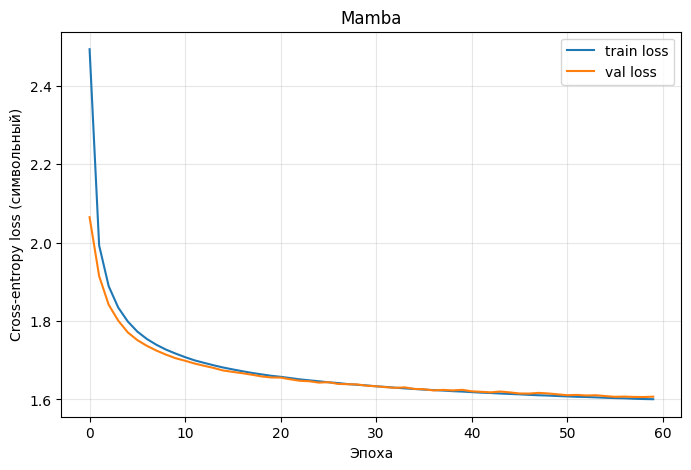

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Эпоха")
plt.ylabel("Cross-entropy loss (символьный)")
plt.title("Mamba")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



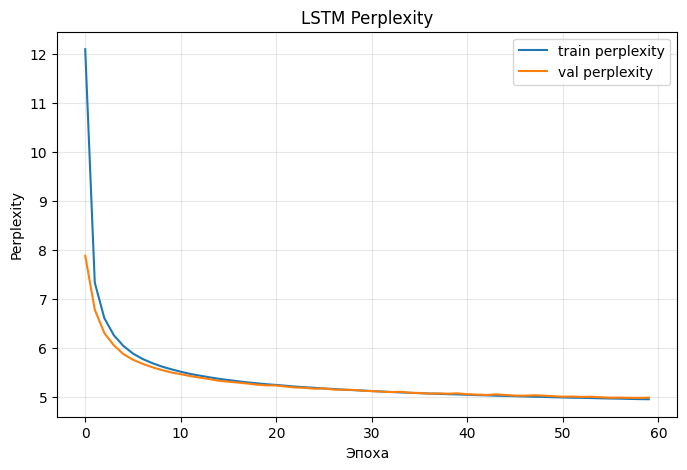

Итоговая perplexity на валидации (последняя эпоха): 4.99
Лучшая perplexity на валидации: 4.98


In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_ppl"], label="train perplexity")
plt.plot(history["val_ppl"], label="val perplexity")

plt.xlabel("Эпоха")
plt.ylabel("Perplexity")
plt.title("LSTM Perplexity")
plt.legend()
plt.grid(alpha=0.3)

plt.show()
print(f"Итоговая perplexity на валидации (последняя эпоха): {history['val_ppl'][-1]:.2f}")
print(f"Лучшая perplexity на валидации: {min(history['val_ppl']):.2f}")

## Генерация текста и нарезка на четверостишия

In [22]:
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model = MambaLM(VOCAB_SIZE, pad_idx=PAD_IDX, **ckpt["config"]).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()

@torch.no_grad()
def generate_poem(model, max_len=300, temperature=0.8, top_k=30):
    model.eval()
    seq = [BOS_IDX]
    for _ in range(max_len):
        x = torch.tensor([seq], device=device)
        logits = model(x)[0, -1] / temperature
        logits[PAD_IDX] = -float("inf")
        logits[BOS_IDX] = -float("inf")
        k = min(top_k, logits.size(-1))
        topk_vals, topk_idx = torch.topk(logits, k)
        probs = F.softmax(topk_vals, dim=-1)
        choice = topk_idx[torch.multinomial(probs, 1)].item()
        if choice == EOS_IDX:
            break
        seq.append(choice)
    return "".join(idx2char[i] for i in seq[1:])


def extract_quatrains(text, n_lines=4):
    lines = [l for l in text.split("\n") if l.strip()]
    quatrains = []
    for i in range(0, len(lines) - n_lines + 1, n_lines):
        chunk = lines[i:i + n_lines]
        if len(chunk) == n_lines:
            quatrains.append("\n".join(chunk))
    return quatrains


In [23]:
N_SAMPLES = 30

all_quatrains = []
for i in range(N_SAMPLES):
    poem = generate_poem(model)
    qs = extract_quatrains(poem)
    all_quatrains.extend(qs)
    print(f"Сгенерированный стих {i + 1}")
    print(poem)
    print()

print(f"Извлечено четверостиший: {len(all_quatrains)}")


Сгенерированный стих 1
Когда́ степи́ны стра́нный красоту́
Его́ благоуха́ет как в беспя́щешь спи́т.

Бородо́й сопрекло́нной, как зра́к.

При́зрак жи́знь молчаё́т.

Сгенерированный стих 2
Весь ме́шь свягу́ю не начина́я
Под красне́й, свою́ в цело́сь.

Мы чу́жду вля́ды, бревня́, как прокляну́ть!..

Осмо́тные 

Сгенерированный стих 3
Гремя́тся со́н в любви́ неве́дом сме́нны,
Что́ взрассла́дость до́лго де́ва стра́сть,
Ещё́ холо́дной тоско́йке,
Тому́ ль си́ним ти́л,
По мо́ре говори́т моя́,
Приве́тся пу́ть, кото́рой сле́д на свои́м,
Пала́ся то́т был ми́лою стра́нной
Жи́л мне стреми́т у ми́г
Сиди́ трево́г бы ска́зка - пле́ть,
Ра́нни

Сгенерированный стих 4
Жара́ю и бо́й семь пе́ссы сутро́пкой...

Сгенерированный стих 5
Наста́л беду́, - в небе́стро в не́ быва́ло,
И со́лнце се́рдце па́сли я́?
Все дру́г вспом бо́ле на зати́мых сти́х.
Я зна́я, сгу́бы вспы́хнул земли́,
И кро́вь слышне́ с цела́,
И взо́р я ра́дость автори́к соро́жий.
Кра́ет о́кна в до́лжной сосле́дни,
В бредь све́чи инё́мся кру́г,
С о

## Сохранение 

In [24]:
with open("vocab.json", "w", encoding="utf-8") as f:
    json.dump({"char2idx": char2idx, "config": ckpt["config"],}, f, ensure_ascii=False, indent=2)

with open("generated_quatrains_mamba.json", "w", encoding="utf-8") as f:
    json.dump(all_quatrains, f, ensure_ascii=False, indent=2)
